<a href="https://colab.research.google.com/github/Peter-Apps/Neutrino-Camp/blob/main/damped_oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>Data Analysis Practice:</h2>
<h3>Damped Oscillator</h3><br>

Here, we are going to explore various ways to test the power of various fitting methods. For our context we will use the classic damped oscillator equation<br> <font size = 10>$$ x(t) = A e^{-\gamma t} \cos(\omega t) $$</font><br> where:

A=amplitude<br>&gamma; = damping coefficient<br>&omega; = angular frequency<br><i>(We'll ignore phase for now)</i><br>
<br>

The code will simulate a noisy set of underdamped oscillator data, then plot those data. Feel free to alter aspects of the plot to get a feel for what the code is doing.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Time array
num_points=1000
t = np.linspace(0, 10, num_points)

#Set the three oscillation parameter values, plus the "noisiness" level in the data
#An optional extension would be to lay out the parameters underlying omega, for different damping scenarios.
sim_A, sim_gamma, sim_omega, noise_level = 1.5, 0.3, 2.5, 0.3


In [ ]:
# the oscillator curve
def damped_oscillator(t, A, gamma, omega):
    return A * np.exp(-gamma * t) * np.cos(omega * t)

# the data to be plotted. you can make it more or less noisy later.
def generate_noisy_data(t, A, gamma, omega, noise_level):
    """Generates synthetic data for a damped oscillator with added noise."""
    theoretical_y = damped_oscillator(t, A, gamma, omega)
    noise = np.random.normal(0, noise_level, theoretical_y.shape)
    noisy_y = theoretical_y + noise
    return noisy_y


# if you want the plot to generate new noisy data each time you change the slider,
# put this line inside the plot_damped_oscillator function below.
noisy_y = generate_noisy_data(t, sim_A, sim_gamma, sim_omega, noise_level)


#just as a sanity check, you can uncomment the line below to see the dataset.
#noisy_y


plt.figure(figsize=(10, 4))
    # Plot simulated data as scatter points
plt.scatter(t, noisy_y, label="Simulated Data", s=10) # s is marker size


plt.title(f"Damped Harmonic Oscillator with Simulated Data")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (cm)")
plt.grid(True)
plt.legend()
plt.show()

<h2>Trying to fit the data</h2>

In the plot below, we have added a curve fit of the same form as the equation above. There are some additional features too:<br><Br>1. There are three slider bars that allow you to adjust the values of A, &gamma; and &omega; and try to dial in the correct fit parameters.<br><br>2. We can not only visually inspect the appearance of the curve fit, but also observe how the &chi;<sup>2</sup> value changes as we adjust the sliders. But what is a "good" chi-square value? <br><br> Thinking about degrees of freedom helps. Our dataset has `num_points` values in it (1000 by default), and we subtract three for the number of fitting parameters (A, &gamma;, &omega;) &mdash; so the degrees of freedom is `num_points - 3`. As a rule of thumb, a good &chi;<sup>2</sup> value should be roughly equal to the degrees of freedom. <i>(If you change `num_points` above, this changes too &mdash; the code cell below always computes the correct value for whatever you've set.)</i>

To follow up on this, recall that there are "confidence levels" usually written in &chi;<sup>2</sup> tables such as "p<0.05", indicating a 95% confidence that the result is statistically significant. If you want to refresh your memory on this, there's a little calculator commented out in a code block just below the plot.

In [ ]:
# Slider bars for plot. I deliberately made ludicrous choices for the min/max and step, and
# commented out more sensible values. use chi-square value to guide you.

# Interesting side note: we never had to actually call the function because the sliders
# automatically do this when the values are adjusted.

@interact(
    #A=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='Amplitude'),
    #gamma=FloatSlider(min=0.0, max=2.0, step=0.05, value=0.2, description='Damping'),
    #omega=FloatSlider(min=0.1, max=10.0, step=0.1, value=2.0, description='Frequency')
    A=FloatSlider(min=0, max=2, step=.1, value=0.0, description='Amplitude'),
    gamma=FloatSlider(min=0.0, max=1, step=.01, value=1, description='Damping'),
    omega=FloatSlider(min=0.1, max=12.0, step=.1, value=2.0, description='Frequency')
)

# here's where we plot the data.
def plot_damped_oscillator(A, gamma, omega):




    # Calculate theoretical curve based on slider values
    y = damped_oscillator(t, A, gamma, omega)

    # Calculate Chi-squared value
    # Assuming a constant uncertainty (sigma) for all data points
    # A simple approach is to use the noise level as an estimate for sigma
    sigma = noise_level
    chi_squared = np.sum(((noisy_y - y) / sigma)**2)



    plt.figure(figsize=(10, 4))
    # Plot simulated data as scatter points
    plt.scatter(t, noisy_y, label="Simulated Data", s=10, alpha=0.3) # s is marker size
    # Plot theoretical curve
    plt.plot(t, y, label=f"Theoretical: A={A}, γ={gamma}, ω={omega}", c="r")

    plt.title(f"Damped Harmonic Oscillator with Simulated Data\nChi-squared: {chi_squared:.2f}")
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement (cm)")
    plt.grid(True)
    plt.legend()
    plt.show()


Reveal the code below to test out &chi;<sup>2</sup> calculations.

In [ ]:
# @title
from scipy.stats import chi2

# Degrees of freedom
degrees_of_freedom = num_points-3

# Desired p-value (for p < 0.05, we look at the 0.05 significance level)
p_value = 0.05

# Calculate the chi-squared value corresponding to this p-value
# We use the inverse survival function (isf) which gives the x value
# such that the probability of getting a chi-squared value > x is equal to the p_value.
chi_squared_critical = chi2.isf(p_value, degrees_of_freedom)

print(f"For {degrees_of_freedom} degrees of freedom, the maximum allowable chi-squared value for p < {p_value} is approximately: {chi_squared_critical:.2f}")

<h2>Visualizations</h2>
The slider bars are a really nice touch (h.t. to Gemini and ChatGPT for showing me how to do this!) but we can try to extend on these ideas with different visualization techniques.<br><BR>Let's try a "heat map" that plots a landscape of amplitude and damping values, while keeping angular frequency fixed.<br><br>Initially, the heat map will be bad, and this is because the plot ranges are poorly chosen. <br><h2>Make sure to adjust the values in this cell to improve the heatmap!</h2>

In [ ]:
# Define the range for the parameters you want to explore.


# I once again made ludicrous choices for these values. Use the inital heatmap to guide you.
# or just cheat and uncomment the better choices.
#A_values = np.linspace(0, 3, 50)
#gamma_values = np.linspace(0.0, .5, 50)
#fixed_omega = 2.5 # Fix omega to a specific value



A_values = np.linspace(0, 2, 50)
gamma_values = np.linspace(0.0, 1, 50)
fixed_omega = 2.5 # Fix omega to a specific value

# Create a grid of parameter values
A_grid, gamma_grid = np.meshgrid(A_values, gamma_values)

# Initialize an array to store the chi-squared values
chi_squared_values = np.zeros(A_grid.shape)

# Generate the noisy data once (using the same parameters as in the interactive plot)
sim_A, sim_gamma, sim_omega, noise_level = 1.5, 0.3, 1.25, 0.1
noisy_y = generate_noisy_data(t, sim_A, sim_gamma, sim_omega, noise_level)
sigma = noise_level # Assuming constant uncertainty

# Calculate chi-squared for each combination of A and gamma
for i in range(A_grid.shape[0]):
    for j in range(A_grid.shape[1]):
        A = A_grid[i, j]
        gamma = gamma_grid[i, j]
        omega = fixed_omega # Use the fixed omega

        theoretical_y = damped_oscillator(t, A, gamma, omega)
        chi_squared = np.sum(((noisy_y - theoretical_y) / sigma)**2)
        chi_squared_values[i, j] = chi_squared

print(f"Chi-squared values calculated for omega = {fixed_omega}")

You can mess around with the threshold stuff to make the heat map more or less striking.

There are also a lot of [color choice](https://matplotlib.org/stable/gallery/color/colormap_reference.html)s to be made! To reverse the gradient, add _r to the end of the colormap name.

In [ ]:
# Define thresholds based on num_points
num_points = len(t) # Make sure num_points is defined from the time array
lower_threshold = num_points
upper_threshold = 15 * num_points

plt.figure(figsize=(10, 7))
plt.imshow(chi_squared_values, origin='lower', aspect='auto',
           extent=[A_values[0], A_values[-1], gamma_values[0], gamma_values[-1]],
           cmap='turbo_r', # Using 'viridis' colormap and reversed
           vmin=lower_threshold, # Set minimum of color scale based on threshold
           vmax=upper_threshold) # Set maximum of color scale based on threshold

plt.colorbar(label='Chi-squared value')
plt.xlabel('Amplitude (A)')
plt.ylabel('Damping (gamma)')
plt.title(f'Chi-squared Heatmap for Fixed Omega = {fixed_omega}')
plt.show()

As you'll see in the neutrino notebooks, making a heat map like this one is a common practice when trying to fit two different parameters at once (like in the 2-flavor oscillation model).

<h2>3D Rendering!</h2>

In the heatmap above, we were restricted to only two parameters because of the 2D plot: the third parameter &omega; had to be fixed at a certain value. <br>So what if we thought of that heatmap as a slice of bread inside a loaf of bread, where every slice represented a different value for &omega;? <br><br>Below is a 3D heatmap with all three parameters plotted. <B><i><font color = "gold">As before, silly choices have been made for the parameter range that sets the axes. </font></i></b>But if you spin the plot around and re-orient, you may see a tiny hint of color in there! <br>

*   Left-click-and-drag (or the laptop / MacBook equivalent) to spin.
*   Right-click-and-drag to move L/R U/D etc.
*   Mouse wheel or two finger on mouse pad to zoom.



In [ ]:
# Define the range for all three parameters
A_values_3d = np.linspace(0, 4, 50) # Reduced points for faster calculation
gamma_values_3d = np.linspace(0.0, 1, 50) # Reduced points
omega_values_3d = np.linspace(1, 4, 50) # Reduced points

# Create a 3D grid of parameter values
A_grid_3d, gamma_grid_3d, omega_grid_3d = np.meshgrid(A_values_3d, gamma_values_3d, omega_values_3d, indexing='ij')

# Initialize an array to store the chi-squared values
chi_squared_values_3d = np.zeros(A_grid_3d.shape)

# Generate the noisy data once (using the same parameters as in the interactive plot)
sim_A, sim_gamma, sim_omega, noise_level = 1.5, 0.3, 2.5, 0.1
noisy_y = generate_noisy_data(t, sim_A, sim_gamma, sim_omega, noise_level)
sigma = noise_level # Assuming constant uncertainty

# Calculate chi-squared for each combination of A, gamma, and omega
for i in range(A_grid_3d.shape[0]):
    for j in range(A_grid_3d.shape[1]):
        for k in range(omega_grid_3d.shape[2]):
            A = A_grid_3d[i, j, k]
            gamma = gamma_grid_3d[i, j, k]
            omega = omega_grid_3d[i, j, k]

            theoretical_y = damped_oscillator(t, A, gamma, omega)
            chi_squared = np.sum(((noisy_y - theoretical_y) / sigma)**2)
            chi_squared_values_3d[i, j, k] = chi_squared

print("Chi-squared values calculated for 3D parameter space.")

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Flatten the 3D grids and chi-squared values for plotting
A_flat = A_grid_3d.flatten()
gamma_flat = gamma_grid_3d.flatten()
omega_flat = omega_grid_3d.flatten()
chi_squared_flat = chi_squared_values_3d.flatten()


In [ ]:
import plotly.graph_objects as go


# Flatten the 3D grids and chi-squared values for plotting (if not already flattened)
# Assuming A_grid_3d, gamma_grid_3d, omega_grid_3d, and chi_squared_values_3d are already calculated
# from the previous steps and are available in the environment.
# If not, you would need to re-run the data generation cell.
A_flat = A_grid_3d.flatten()
gamma_flat = gamma_grid_3d.flatten()
omega_flat = omega_grid_3d.flatten()
chi_squared_flat = chi_squared_values_3d.flatten()

# Define thresholds based on num_points
num_points = len(t) # Make sure num_points is defined from the time array
lower_threshold = 2 * num_points
upper_threshold = 10 * num_points


# Create the 3D scatter plot using Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=A_flat,
    y=gamma_flat,
    z=omega_flat,
    mode='markers',
    marker=dict(
        size=5,
        color=chi_squared_flat,  # Color points by chi-squared value
        colorscale='turbo_r',    # Changed colormap to 'Plasma' and reversed
        opacity=0.02,
        cmin=lower_threshold,  # Set the minimum of the color scale based on threshold
        cmax=upper_threshold # Set the maximum of the color scale based on threshold
    )
)])

# Update layout for better viewing
fig.update_layout(
    title=f'Interactive 3D Chi-squared Landscape (Plotly)\nColor Scale: {lower_threshold:.0f} to {upper_threshold:.0f}',
    scene=dict(
        xaxis_title='Amplitude (A)',
        yaxis_title='Damping (gamma)',
        zaxis_title='Frequency (omega)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Show the plot
fig.show()

## Other Options for Machine Learning

We've got an array of different methods here, some good and some bad. Let's try them out!


In [ ]:
# Step 1: Prepare the data for machine learning

# Generate one fixed dataset for this whole ML comparison section. We set an explicit
# seed and regenerate the data here (rather than relying on whatever "noisy_y" was left
# over from an earlier cell) so results are reproducible and don't depend on which
# cells you happened to run above, or in what order.
np.random.seed(42)
ml_A, ml_gamma, ml_omega, ml_noise_level = 1.5, 0.3, 2.5, 0.1
ml_noisy_y = generate_noisy_data(t, ml_A, ml_gamma, ml_omega, ml_noise_level)

# Reshape the time array to be a 2D array (number of samples, number of features)
# In this case, each time point is a sample with one feature (the time value itself)
X = t.reshape(-1, 1)

# The target variable is the noisy data
y = ml_noisy_y

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")



### First up: Linear regression! Ought to be perfect for this dataset 😀

In [ ]:
# Step 5 (cont.): Implement and evaluate Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize a Linear Regression model object
model_linreg = LinearRegression()

# Train the Linear Regression model using the training data
model_linreg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linreg = model_linreg.predict(X_test)

# Evaluate the model's performance using Mean Squared Error (MSE)
mse_linreg = mean_squared_error(y_test, y_pred_linreg)
print(f"Linear Regression Mean Squared Error: {mse_linreg:.4f}")

# Create a scatter plot of the test data and overlay a line plot of the predictions
plt.figure(figsize=(10, 4))
plt.scatter(X_test, y_test, label="Test Data", s=10, alpha=0.5)

# Sort the test data by X values for a cleaner line plot of predictions
sorted_indices = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_indices], y_pred_linreg[sorted_indices], color='orange', label="Linear Regression Predictions")

plt.title("Linear Regression Fit")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.show()


### Next: Polynomial Regression.

My students love this one until I tell them to zoom out 🙄

In [ ]:
# Step 5 (cont.): Implement and evaluate Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Assuming X and y are already prepared from Step 1
# X_train, X_test, y_train, y_test are also assumed to be available

# Define the degree of the polynomial
# A higher degree can fit more complex curves but can also lead to overfitting
polynomial_degree = 8 # How many terms do you want?

# Create polynomial features
# The transformer will add polynomial terms up to the specified degree
poly_features = PolynomialFeatures(degree=polynomial_degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test) # Use transform on test set to avoid data leakage

print(f"Original training features shape: {X_train.shape}")
print(f"Polynomial training features shape: {X_train_poly.shape}")

# Initialize and train a Linear Regression model on the polynomial features
model_polyreg = LinearRegression()
model_polyreg.fit(X_train_poly, y_train)

# Make predictions on the test set using the polynomial features
y_pred_polyreg = model_polyreg.predict(X_test_poly)

# Evaluate the model's performance using Mean Squared Error (MSE)
mse_polyreg = mean_squared_error(y_test, y_pred_polyreg)
print(f"Polynomial Regression (degree {polynomial_degree}) Mean Squared Error: {mse_polyreg:.4f}")

# Create a scatter plot of the test data and overlay a line plot of the predictions
plt.figure(figsize=(10, 4))
plt.scatter(X_test, y_test, label="Test Data", s=10, alpha=0.5)

# Sort the test data by X values for a cleaner line plot of predictions
sorted_indices = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_indices], y_pred_polyreg[sorted_indices], color='orange', label=f"Polynomial Regression (degree {polynomial_degree}) Predictions")

plt.title(f"Polynomial Regression (degree {polynomial_degree}) Fit")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.show()



---


### Now: Logistic regression.

A key feature of logistic regression is that it uses the "sigmoid" function you see in logistic curves. This is a good choice when you want to classify a dataset into category 1 or 0, because the sigmoid has big sections that are flat at 0 and 1.

Is it a good choice here???



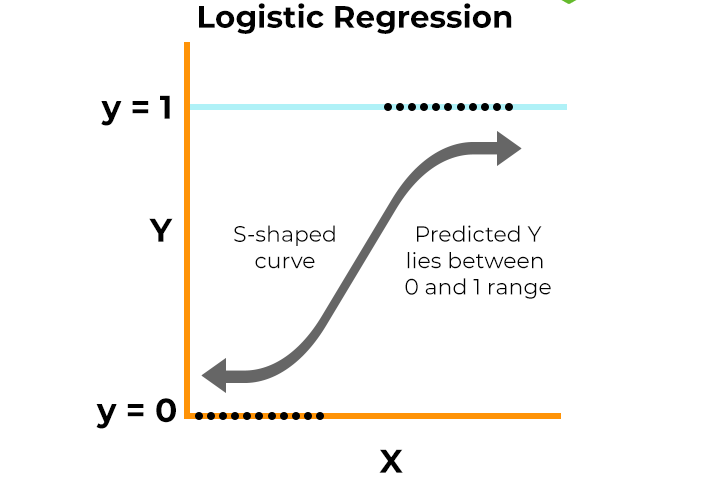


From [spiceworks.com](https://www.spiceworks.com/tech/artificial-intelligence/articles/what-is-logistic-regression/)


In [ ]:
# Step 2: Train and evaluate Logistic Regression


# Initialize and train the Logistic Regression model
# Note: Logistic Regression is for classification. Applying it to continuous data
# directly as a regression task is not its intended use and will likely perform poorly.
# We might encounter errors or need to discretize the target variable.
try:
    model_lr = LogisticRegression()
    model_lr.fit(X_train, y_train)

    # Make predictions (these predictions will be class labels if target was discretized)
    y_pred_lr = model_lr.predict(X_test)

    # Evaluate the model (metrics like accuracy are for classification)
    # Since the target is continuous, accuracy is not a suitable metric.
    # We could potentially look at how it groups continuous values if it runs.
    # A more appropriate metric for regression would be Mean Squared Error (MSE),
    # but Logistic Regression doesn't directly predict continuous values.
    # Let's calculate MSE to see what values come out, but interpret with caution.
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    print(f"Logistic Regression Mean Squared Error (attempted): {mse_lr:.4f}")

    # Since it's classification, let's also see unique predicted values
    print(f"Unique predicted values by Logistic Regression: {np.unique(y_pred_lr)}")

except Exception as e:
    print(f"Could not train Logistic Regression directly on continuous data: {e}")
    print("Logistic Regression is designed for classification. The target variable (noisy_y) is continuous.")
    print("To use Logistic Regression, the target variable would need to be discretized into categories.")

## Decision Tree

Turns out logistic regression wasn't great, though it could be nice when you want to do something like classify a neutrino as being one type or another!

Before jumping to Random Forest, let's look at a single decision tree. A decision tree just asks a series of yes/no questions about the input (here, just the time value) and lands on a predicted number. Unlike almost everything else in this notebook, you can print out the *exact* rules it learned and trace them by hand.

In [ ]:
# Step 2.5: Train and evaluate a single Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import mean_squared_error

# Try changing this! A shallow tree (small max_depth) gives simple, human-readable rules.
# A deep tree (or max_depth=None) fits the training data almost perfectly but overfits.
tree_depth = 3

model_tree = DecisionTreeRegressor(max_depth=tree_depth, random_state=42)
model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f"Decision Tree (max_depth={tree_depth}) Mean Squared Error: {mse_tree:.4f}")
print(f"Number of leaves (i.e. number of distinct predictions it can make): {model_tree.get_n_leaves()}")

# Print the actual rules the tree learned -- you can trace these by hand
print("\nThe rules this tree learned:\n")
print(export_text(model_tree, feature_names=["time"]))

# Plot predictions against the test data
plt.figure(figsize=(10, 4))
plt.scatter(X_test, y_test, label="Test Data", s=10, alpha=0.5)
sorted_indices = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_indices], y_pred_tree[sorted_indices], color='purple', label=f"Decision Tree (depth={tree_depth}) Predictions")
plt.title(f"Decision Tree Regressor Fit (depth={tree_depth})")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.show()


## Random Forest

You just saw what one decision tree can do. Random Forest's idea is simple: what if we trained 100 different decision trees (each seeing a slightly different random subset of the data) and averaged their predictions together? That's it -- that's the whole idea.

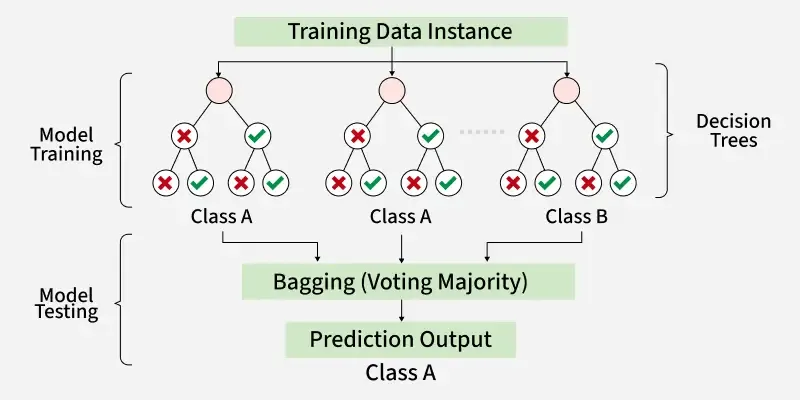

From [geeksforgeeks.org](https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/)

In [ ]:
# Step 3: Train and evaluate Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Re-split using the SAME random_state as every other model in this section, so all
# models are compared on identical train/test data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42) # Using 100 trees as a starting point
model_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest Regressor Mean Squared Error: {mse_rf:.4f}")

# Optionally, plot the Random Forest predictions against the actual test data
plt.figure(figsize=(10, 4))
plt.scatter(X_test, y_test, label="Test Data", s=10, alpha=0.5)
# Sort the test data by X values for a cleaner line plot of predictions
sorted_indices = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_indices], y_pred_rf[sorted_indices], color='red', label="Random Forest Predictions")
plt.title("Random Forest Regressor Fit")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.show()

## Neural Network

I [politely asked](https://slate.com/technology/2014/07/rokos-basilisk-the-most-terrifying-thought-experiment-of-all-time.html) ChatGPT to define a neural network in 100 words or fewer:
"Neural networks are machine learning models that mimic the structure of the human brain. They consist of layers of nodes (neurons), where each neuron is connected to others with weighted links. Input data is fed into the input layer, processed through hidden layers, and produces output. During training, the network adjusts the weights of connections based on the error in predictions, using a process called backpropagation and optimization algorithms like gradient descent. Through many iterations, the network learns to recognize patterns and make accurate predictions. Neural networks are widely used for tasks like image recognition, language processing, and more."

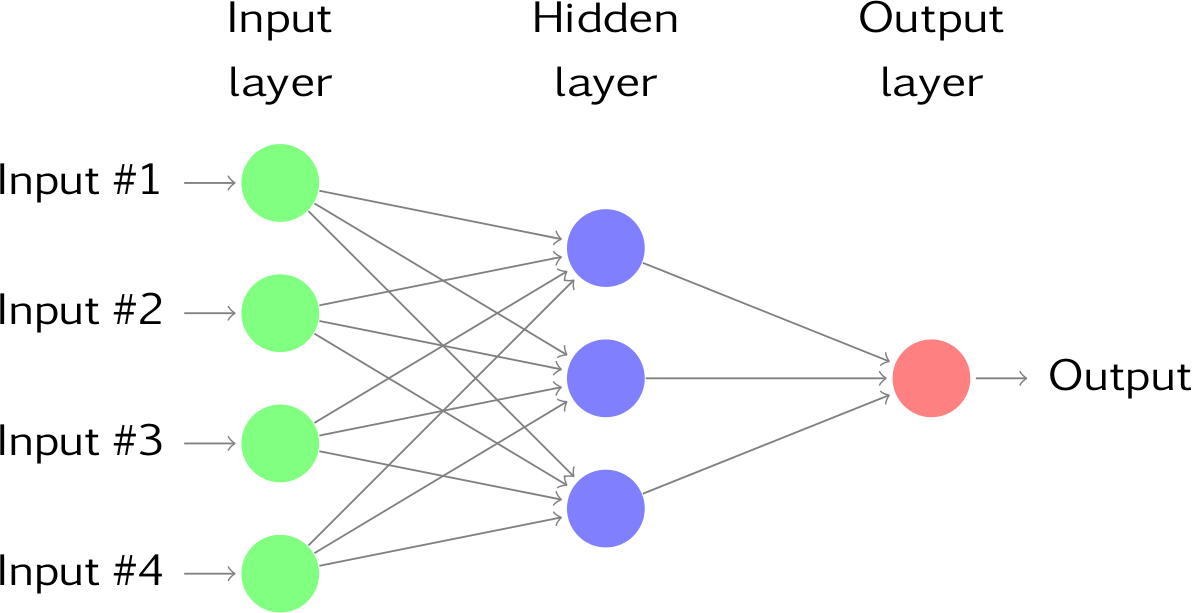

From Forecasting: Principles & Practice by Hyndman & Athanasopoulos, on [otexts.com](https://otexts.com/fpp2/nnetar.html)

In [ ]:
# Step 4: Design and train a Neural Network system

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split data into training and testing sets (if not already split)
# Assuming X and y are already prepared from Step 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Design the neural network model
# A simple model with a few layers might be a good starting point
model_nn = Sequential([
    Input(shape=(X_train.shape[1],)), # Input layer using Input object
    Dense(64, activation='relu'), # Hidden layer (no input_shape needed here)
    Dense(64, activation='relu'), # Hidden layer
    Dense(1) # Output layer (predicting a single continuous value)
])

# Compile the model
model_nn.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # Using Mean Squared Error as the loss function

# Train the model
# We'll train for a certain number of epochs and use a validation split to monitor performance
history = model_nn.fit(X_train, y_train, epochs=1000, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model on the test set
mse_nn = model_nn.evaluate(X_test, y_test, verbose=0)
print(f"Neural Network Mean Squared Error: {mse_nn:.4f}")

# Make predictions on the test set
y_pred_nn = model_nn.predict(X_test).flatten() # Flatten predictions as predict returns a 2D array

# Optionally, plot the Neural Network predictions against the actual test data
plt.figure(figsize=(10, 4))
plt.scatter(X_test, y_test, label="Test Data", s=10, alpha=0.5)
# Sort the test data by X values for a cleaner line plot of predictions
sorted_indices = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_indices], y_pred_nn[sorted_indices], color='green', label="Neural Network Predictions")
plt.title("Neural Network Fit")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.show()

In [ ]:
# Save the nn model so we won't have to train it again.
model_nn.save("nn_fit.keras")


## Other Suitable Machine Learning Tools for Educational Exploration

While Logistic Regression, Random Forest, and Neural Networks offer powerful approaches, exploring other simpler or fundamentally different algorithms can deepen understanding for beginners. Here are a few suggestions suitable for educational purposes in the context of physics data analysis:

### 1. Linear Regression

*   **Problem Type:** Primarily used for **regression** problems, where the goal is to predict a continuous output variable.
*   **Basic Idea:** Linear Regression finds the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the distance between the predicted values and the actual data points. It assumes a linear relationship between the input features and the output variable. The model learns the coefficients (slope and intercept) of this line.
*   **Suitability for Beginners:** It's one of the simplest and most intuitive regression algorithms. Its mathematical basis is straightforward, making it easy to understand how the model makes predictions. It's an excellent starting point for understanding fundamental concepts like fitting models to data and evaluating performance with metrics like Mean Squared Error.
*   **Difference from Explored Models:**
    *   **vs. Logistic Regression:** Linear Regression is for continuous output (regression), while Logistic Regression is for categorical output (classification).
    *   **vs. Random Forest:** Linear Regression assumes a linear relationship, while Random Forest can capture complex, non-linear relationships through decision trees. Linear Regression is much simpler and less computationally intensive.
    *   **vs. Neural Networks:** Linear Regression is a single-layer linear model, whereas Neural Networks can have multiple layers and non-linear activation functions, allowing them to model highly complex patterns. Linear Regression is a foundational concept often used as a building block or benchmark.

### 2. Polynomial Regression

*   **Problem Type:** Used for **regression** problems, especially when the relationship between the input features and the output variable is **non-linear**.
*   **Basic Idea:** Polynomial Regression extends Linear Regression by adding polynomial terms (e.g., x^2, x^3) to the model. It still fits a linear model to the *transformed* features. By including these higher-order terms, the model can fit curves to the data, capturing non-linear trends.
*   **Suitability for Beginners:** It is a natural extension of Linear Regression and helps illustrate how simple models can be adapted to handle non-linear relationships without resorting to very complex algorithms. It introduces the concept of feature engineering (creating new features from existing ones).
*   **Difference from Explored Models:**
    *   **vs. Linear Regression:** Explicitly models non-linear relationships using polynomial terms, whereas Linear Regression is strictly linear.
    *   **vs. Random Forest/Neural Networks:** While it can model non-linearity, it's limited to polynomial forms. Random Forest and Neural Networks can model a much wider variety of complex non-linear patterns without requiring manual feature engineering of polynomial terms. It's less flexible but more interpretable than these complex models.

### 3. Support Vector Machines (for Regression - SVR)

*   **Problem Type:** Can be used for both classification (SVC) and **regression (SVR)**.
*   **Basic Idea:** Instead of finding a line that minimizes the sum of squared errors (like Linear Regression), SVR finds a hyperplane that has a maximum "margin" around it, such that as many data points as possible fall within that margin. The model tries to fit the best line (or curve, using kernels) while allowing for a certain tolerance (epsilon) for errors. It focuses on the data points that lie on the edge of this margin (support vectors).
*   **Suitability for Beginners:** While the underlying theory can be a bit more complex than Linear Regression, the core idea of finding a line/hyperplane with a margin is conceptually understandable. It introduces the powerful concept of "kernels," which allow SVR to implicitly map data into higher dimensions to find linear relationships in that space, effectively fitting non-linear curves in the original space. This is a key idea in many advanced ML algorithms.
*   **Difference from Explored Models:**
    *   **vs. Linear Regression:** SVR uses a margin-based approach and can handle non-linearity through kernels, unlike basic Linear Regression.
    *   **vs. Random Forest/Neural Networks:** SVR's approach is different from tree-based methods (Random Forest) or layered networks (Neural Networks). SVR's performance is often heavily influenced by the choice of kernel function and its parameters, offering a different set of tuning considerations. It can be particularly effective in high-dimensional spaces.

These algorithms provide a good stepping stone for understanding different modeling paradigms and can be implemented and visualized relatively easily for educational purposes, offering valuable insights into how different ML techniques approach the task of fitting data.

In [ ]:
# Final comparison, now a code cell so the MSE values actually get filled in
# (a markdown cell can't evaluate the {mse_rf:.4f} etc. placeholders below).
from IPython.display import Markdown, display

summary = f"""
## Comparison and Suitability of ML Models for Damped Oscillator Data

We have explored several machine learning models for fitting simulated damped oscillator data: Logistic Regression (which was found unsuitable), a single Decision Tree, Random Forest Regressor, a simple Neural Network, and Polynomial Regression. We also compared them to the analytical solution and interactive fitting methods earlier.

Here's a comparison of their performance and characteristics, particularly focusing on their suitability for physics teachers new to machine learning:

**Model Performance (on this specific dataset and configurations):**

*   **Decision Tree (single tree):** MSE: {mse_tree:.4f}
*   **Random Forest Regressor:** MSE: {mse_rf:.4f}
*   **Simple Neural Network:** MSE: {mse_nn:.4f}
*   **Polynomial Regression (Degree {polynomial_degree}):** MSE: {mse_polyreg:.4f}
*   **Logistic Regression:** Not applicable (classification model for continuous data).

*Note: The MSE values are specific to the dataset generated in this notebook run and the chosen hyperparameters. Performance can vary with different data or tuning.*

**Comparison and Suitability for Physics Teachers:**

| Feature            | Decision Tree (single) | Logistic Regression                      | Random Forest Regressor                      | Simple Neural Network                        | Polynomial Regression (Degree {polynomial_degree}) |
| :----------------- | :---------------------------------------------- | :--------------------------------------- | :------------------------------------------- | :------------------------------------------- | :----------------------------------------------- |
| **Problem Type**   | Regression | Classification                           | Regression                                   | Regression                                   | Regression                                       |
| **Performance**    | Fair (MSE: {mse_tree:.4f}) | Not Applicable                           | Good (MSE: {mse_rf:.4f})                     | Moderate (MSE: {mse_nn:.4f})                 | Good (MSE: {mse_polyreg:.4f})                    |
| **Visual Fit**     | Blocky/piecewise (fewer, larger steps) | N/A                                      | Can be piecewise/jagged                      | Smooth, continuous curve fit                 | Smooth curve fit (can oscillate if degree high) |
| **Conceptual Ease**| Most intuitive of all (readable yes/no rules) | Intuitive (linear boundary) but wrong type | More intuitive (tree-based ensemble)         | Less intuitive (layered network, training)   | Intuitive extension of Linear Regression       |
| **Impl. Ease**     | Very straightforward | Straightforward (for classification)     | Relatively straightforward                   | Straightforward in libraries, but more tuning | Straightforward                                  |
| **Non-linearity**  | Can capture non-linearity (limited by depth) | N/A                                      | Can capture complex non-linearity             | Can capture complex non-linearity             | Can capture polynomial non-linearity             |
| **Interpretability**| Fully (print the exact rules) | Highly (coeffs) but wrong type           | Moderately (feature importance)              | Less interpretable ("black box")             | Moderately (coefficients for polynomial terms) |

**Discussion:**

*   **Logistic Regression:** While simple conceptually for classification, its unsuitability for continuous regression problems is a fundamental point to convey. It serves as a good example of choosing the right tool for the right job.
*   **Decision Tree (single):** The most transparent model here by far -- you can print the exact learned rules and a student could trace a prediction by hand. It underperforms the ensemble version (Random Forest) because one shallow tree can only make a limited number of distinct predictions -- try increasing `tree_depth` above and watch the MSE drop as it starts to overfit.
*   **Random Forest Regressor:** Performed well in this case. Its tree-based nature can be explained with analogies. It's a powerful non-linear regression tool that is relatively easy to implement. Its piecewise predictions might contrast nicely with the smooth analytical solution.
*   **Simple Neural Network:** Achieved a moderate MSE. While powerful, its "black box" nature and the complexity of its training process can be challenging for beginners to fully grasp. It demonstrates the ability to learn complex patterns and produce smooth fits, but requires more background to understand *why* it works.
*   **Polynomial Regression:** Performed well, achieving an MSE similar to or better than the other regression models in this test. It's an excellent tool for introducing how to fit non-linear data by transforming features, which is a crucial concept in ML. It's conceptually simpler than Random Forest or complex Neural Networks and the resulting polynomial equation offers some interpretability.

**Suitability for Physics Teachers:**

*   **Starting Point:** **Polynomial Regression** (after Linear Regression) is arguably the most suitable starting point among the regression models explored here for physics teachers new to ML. Its connection to fitting curves with equations is familiar, and feature engineering (creating polynomial terms) is a clear concept.
*   **Intermediate:** **Random Forest** offers a step into ensemble methods and tree-based logic, providing a different paradigm for fitting non-linear data, while still being relatively accessible to implement.
*   **More Advanced:** **Neural Networks** are powerful but require more foundational understanding. They are better introduced after simpler models to highlight their ability to learn complex features automatically, but the "how" is less transparent for beginners.

In conclusion, for physics teachers introducing ML to students, starting with simpler, more interpretable models like Linear and Polynomial Regression, then moving to Random Forest, and finally introducing Neural Networks based on the audience's mathematical background and the depth of exploration desired, seems like a logical progression. This allows for contrasting different modeling philosophies and understanding the trade-offs between interpretability and complexity.
"""

display(Markdown(summary))
